In [1]:
import os
import numpy as np
import pandas as pd
import h5py
import modiscolite

BASE_DIR = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap'
FG_DIR = f'{BASE_DIR}/data/foregrounds'
MUT_DIR = f'{BASE_DIR}/data/mutagenesis_lib'
ACTIVITY_CSV = f'{BASE_DIR}/data/activity_lib/k562_activity_library.csv'
MODISCO_DIR = f'{BASE_DIR}/motif_context_swap/motif_annotation/modisco_results'
os.makedirs(MODISCO_DIR, exist_ok=True)

# Load activity library for seq_id -> bin mapping
activity_df = pd.read_csv(ACTIVITY_CSV, usecols=['seq_id', 'activity_bin'])
bin_map = dict(zip(activity_df['seq_id'], activity_df['activity_bin']))

# Collect foregrounds and WT one-hots
wt_onehots = []
foregrounds = []
loaded_ids = []

for seq_id in sorted(os.listdir(FG_DIR)):
    fg_path = f'{FG_DIR}/{seq_id}/foreground_scaled.npy'
    if not os.path.exists(fg_path) or os.path.getsize(fg_path) == 0:
        continue
    activity_bin = bin_map.get(seq_id)
    if activity_bin is None:
        continue
    mut_path = f'{MUT_DIR}/{activity_bin}_{seq_id}.h5'
    if not os.path.exists(mut_path):
        continue
    with h5py.File(mut_path, 'r') as f:
        wt_ohe = f['wt_sequence'][:].astype(np.float32)  # (230, 4)
        #print(wt_ohe.shape)
    
    try:
    
        fg = np.load(fg_path).astype(np.float32)

    except: 
        print('seq not there')
        
    wt_onehots.append(wt_ohe)
    foregrounds.append(fg)
    loaded_ids.append(seq_id)

wt_onehots = np.array(wt_onehots, dtype=np.float32)
foregrounds = np.array(foregrounds, dtype=np.float32)

print(f'Loaded {len(loaded_ids)} sequences')
print(f'One-hots: {wt_onehots.shape}')
print(f'Foregrounds: {foregrounds.shape}')

seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
Loaded 1085 sequences
One-hots: (1085, 230, 4)
Foregrounds: (1085, 230, 4)


In [2]:
## Run TF-MoDISco on scaled foregrounds

modisco_kwargs = dict(
    sliding_window_size=21,
    flank_size=10,
    target_seqlet_fdr=0.05,
    min_metacluster_size=100,
    final_min_cluster_size=20,
    min_num_to_trim_to=30,
    min_passing_windows_frac=0.03,
    max_seqlets_per_metacluster=20000,
    nearest_neighbors_to_compute=500,
    affmat_correlation_threshold=0.15,
    subcluster_perplexity=50,
    min_ic_in_window=0.6,
    n_leiden_runs=50,
    verbose=True,
)

print('Running TF-MoDISco on SEAM Foreground attributions')
print('=' * 60)
pos_fg, neg_fg = modiscolite.tfmodisco.TFMoDISco(
    one_hot=wt_onehots,
    hypothetical_contribs=foregrounds,
    **modisco_kwargs,
)

h5_path = f'{MODISCO_DIR}/modisco_foreground.h5'
modiscolite.io.save_hdf5(h5_path, pos_fg, neg_fg, window_size=wt_onehots.shape[1])
print(f'\n{len(pos_fg) if pos_fg else 0} pos patterns, {len(neg_fg) if neg_fg else 0} neg patterns')
print(f'Saved: {h5_path}')

Running TF-MoDISco on SEAM Foreground attributions
Using 1082 positive seqlets

7 pos patterns, 0 neg patterns
Saved: /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap/motif_context_swap/motif_annotation/modisco_results/modisco_foreground.h5


In [3]:
## Extract seqlet counts and CWMs

def extract_modisco_stats(h5_path):
    stats = {'pos_patterns': [], 'neg_patterns': [],
             'pos_seqlet_counts': [], 'neg_seqlet_counts': [],
             'total_pos_seqlets': 0, 'total_neg_seqlets': 0}
    with h5py.File(h5_path, 'r') as f:
        for metacluster, key_prefix in [('pos_patterns', 'pos'), ('neg_patterns', 'neg')]:
            if metacluster not in f:
                continue
            grp = f[metacluster]
            for pattern_name in sorted(grp.keys()):
                pat = grp[pattern_name]
                cwm = pat['contrib_scores'][:]
                n_seqlets = int(pat['seqlets']['n_seqlets'][0])
                stats[f'{key_prefix}_patterns'].append(cwm)
                stats[f'{key_prefix}_seqlet_counts'].append(n_seqlets)
                stats[f'total_{key_prefix}_seqlets'] += n_seqlets
    return stats

stats = extract_modisco_stats(h5_path)
print(f"{len(stats['pos_patterns'])} pos patterns, {stats['total_pos_seqlets']} total pos seqlets")
print(f"{len(stats['neg_patterns'])} neg patterns, {stats['total_neg_seqlets']} total neg seqlets")
for i, (cwm, cnt) in enumerate(zip(stats['pos_patterns'], stats['pos_seqlet_counts'])):
    print(f'  pos_pattern_{i}: {cwm.shape}, {cnt} seqlets')

7 pos patterns, 649 total pos seqlets
0 neg patterns, 0 total neg seqlets
  pos_pattern_0: (50, 4), 200 seqlets
  pos_pattern_1: (50, 4), 153 seqlets
  pos_pattern_2: (50, 4), 145 seqlets
  pos_pattern_3: (50, 4), 59 seqlets
  pos_pattern_4: (50, 4), 46 seqlets
  pos_pattern_5: (50, 4), 23 seqlets
  pos_pattern_6: (50, 4), 23 seqlets


In [7]:
## TOMTOM Annotation — match patterns to known motifs
from modiscolite.report import report_motifs, tomtomlite_dataframe

MEME_DB = '/grid/wsbs/home_norepl/pmantill/MEME_stuff/JASPAR2024_CORE_vertebrates_non-redundant_pfms_meme.txt'

report_dir = f'{MODISCO_DIR}/report_foreground'
report_motifs(
    modisco_h5py=h5_path,
    output_dir=report_dir, img_path_suffix='',
    meme_motif_db=MEME_DB, is_writing_tomtom_matrix=True,
    top_n_matches=3, trim_threshold=0.3, ttl=True,
)
print(f'Report saved to {report_dir}/motifs.html')

tomtom_df = tomtomlite_dataframe(
    h5_path, meme_motif_db=MEME_DB,
    pattern_groups=['pos_patterns', 'neg_patterns'],
    top_n_matches=3, output_dir=None
)
print('\n=== TOMTOM matches ===')
print(tomtom_df.to_string())



Report saved to /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap/motif_context_swap/motif_annotation/modisco_results/report_foreground/motifs.html

=== TOMTOM matches ===
                 match0         pval0               match1         pval1          match2         pval2
0         MA0599.1 KLF5  1.135954e-07        MA1959.2 KLF7  4.747328e-07   MA0493.3 KLF1  1.743715e-06
1       MA0750.3 ZBTB7A  2.347041e-08        MA0076.3 ELK4  1.773366e-07   MA0645.2 ETV6  3.155952e-07
2         MA0060.4 NFYA  5.031322e-05        MA0502.3 NFYB  1.882267e-04   MA1644.2 NFYC  2.054624e-04
3         MA1929.2 CTCF  1.626579e-08        MA1930.2 CTCF  1.343982e-07  MA1636.2 CEBPG  1.743752e-05
4  MA0140.3 GATA1::TAL1 -2.913225e-13        MA1930.2 CTCF  8.707555e-05   MA1929.2 CTCF  1.317514e-04
5    MA1132.2 JUN::JUNB  3.616835e-09  MA1128.2 FOSL1::JUN  1.032325e-06  MA1633.2 BACH1  1.966158e-06
6         MA1929.2 CTCF  4.237499e-12        MA0139.2 CTCF  2.198863e-11   MA1930.2

In [8]:
## BH FDR correction on TOMTOM p-values
from statsmodels.stats.multitest import multipletests

pvals = pd.concat([tomtom_df[f'pval{i}'] for i in range(3)]).values
_, qvals, _, _ = multipletests(pvals, method='fdr_bh')
n = len(tomtom_df)
for i in range(3):
    tomtom_df[f'qval{i}'] = qvals[i*n:(i+1)*n]

qval_cols = [c for c in tomtom_df.columns if c.startswith('match') or c.startswith('qval')]
print('=== TOMTOM matches (q-values) ===')
print(tomtom_df[qval_cols].to_string())

ModuleNotFoundError: No module named 'statsmodels'

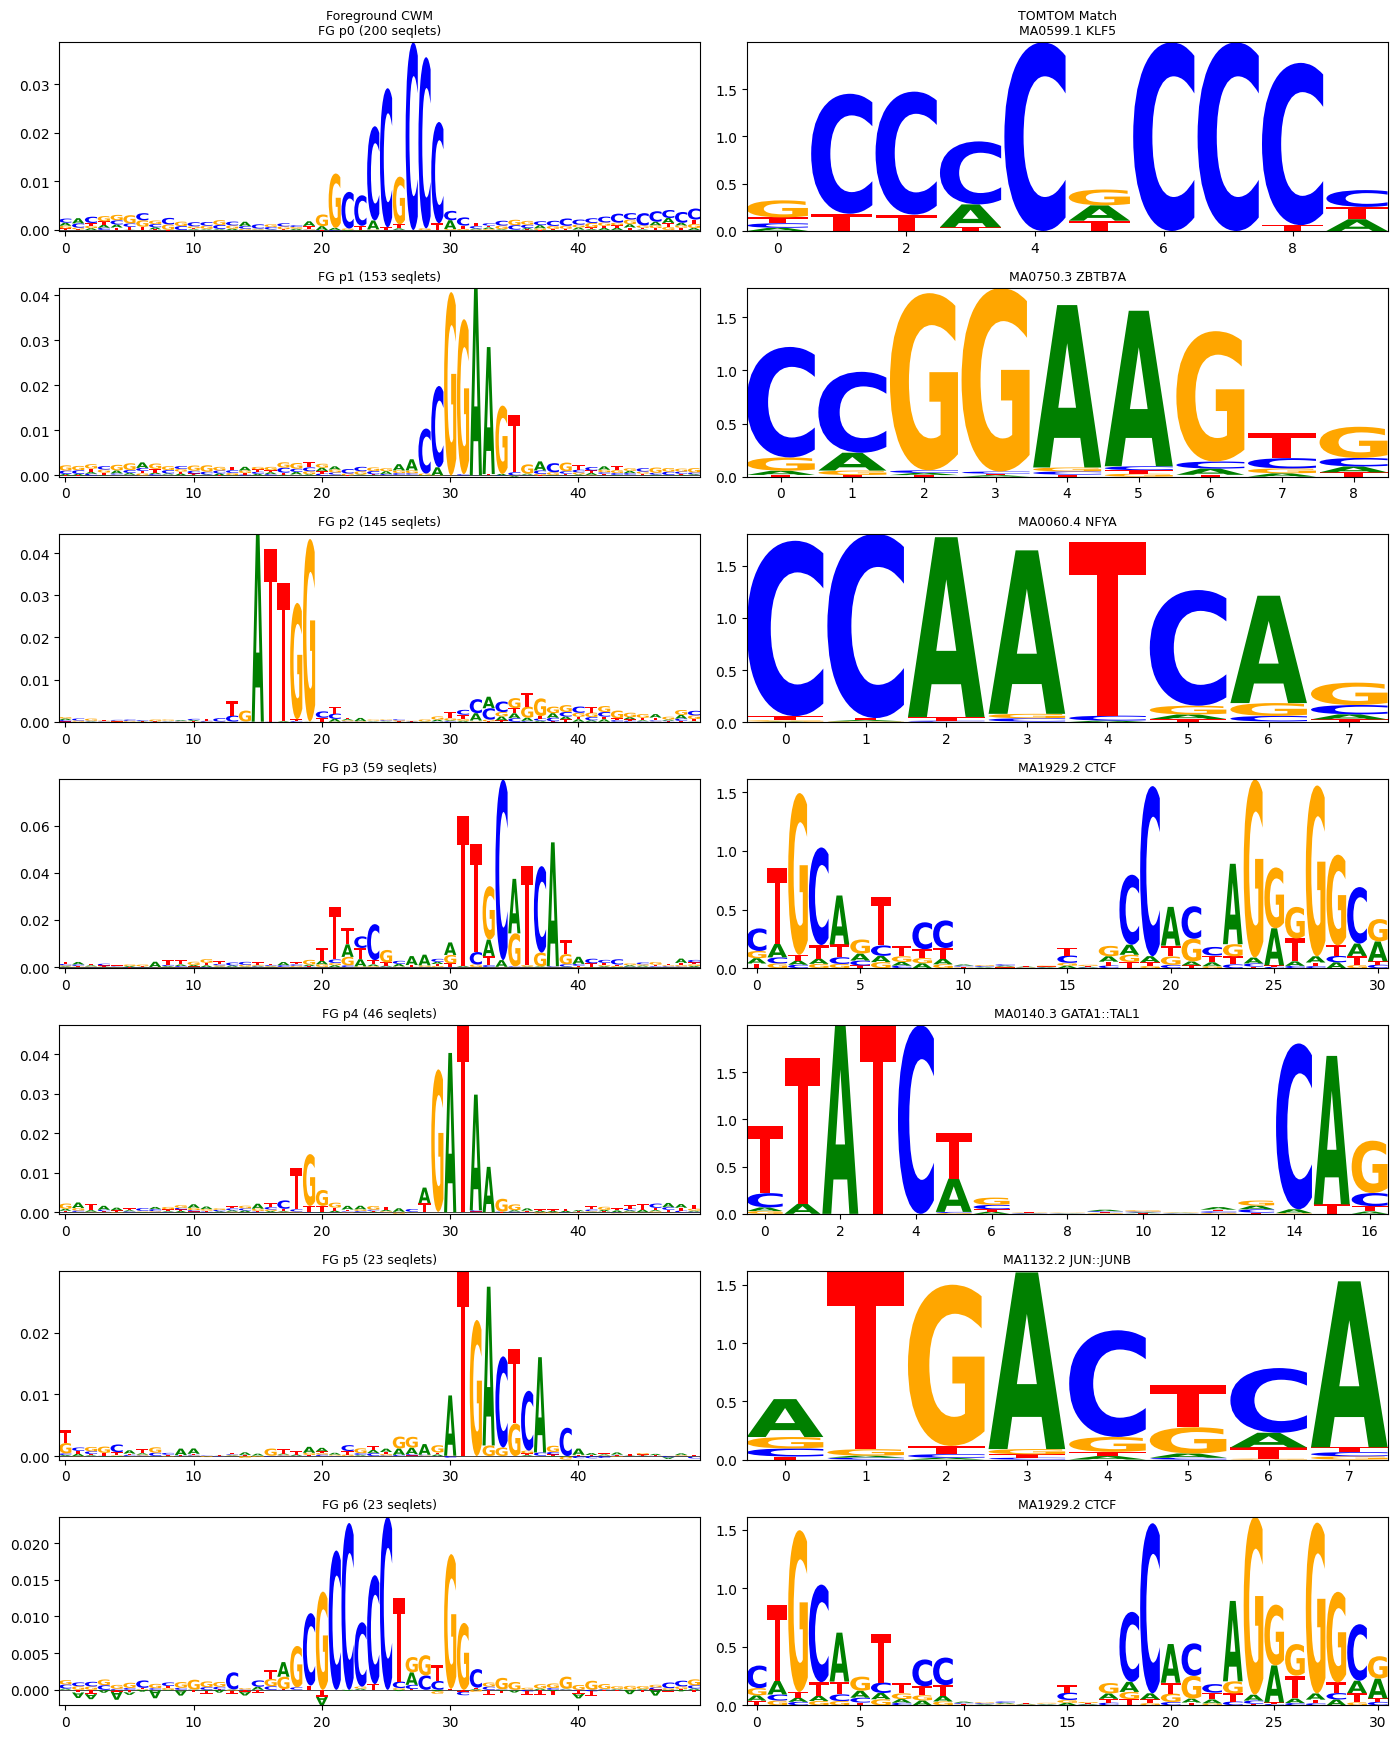

In [15]:

## Pattern logos: FG CWM | TOMTOM best match
import matplotlib.pyplot as plt
import logomaker

# Inline MEME parser (avoids memelite numba bug)
def read_meme(filename):
    import numpy as _np
    motifs = {}
    with open(filename, 'r') as infile:
        motif, width, i = None, None, 0
        for line in infile:
            if motif is None:
                if line[:5] == 'MOTIF':
                    motif = line.replace('MOTIF ', '').strip("\r\n")
                else:
                    continue
            elif width is None:
                if line[:6] == 'letter':
                    width = int(line.split()[5])
                    pwm = _np.zeros((width, 4))
            elif i < width:
                pwm[i] = list(map(float, line.strip("\r\n").split()))
                i += 1
            else:
                motifs[motif] = pwm.T
                motif, width, i = None, None, 0
    return motifs

motifs_db = read_meme(MEME_DB)
motifs_db = {name: pwm.T for name, pwm in motifs_db.items()}  # (4, L) -> (L, 4)

def get_patterns_and_counts(h5_path):
    patterns, counts = [], []
    with h5py.File(h5_path, 'r') as f:
        for group in ['pos_patterns', 'neg_patterns']:
            if group not in f:
                continue
            key = lambda x: int(x[0].split('_')[-1])
            for _, pat in sorted(f[group].items(), key=key):
                patterns.append(pat['contrib_scores'][:])
                counts.append(int(pat['seqlets']['n_seqlets'][0]))
    return patterns, counts

fg_pats, fg_counts = get_patterns_and_counts(h5_path)
fg_names = tomtom_df['match0'].values
n_fg = len(fg_pats)

def get_tomtom_ppm(name, db):
    if name in db:
        return db[name]
    short = name.split()[0]
    for k, v in db.items():
        if k.startswith(short):
            return v
    return None

background = np.array([0.25, 0.25, 0.25, 0.25])

def compute_ic(ppm, bg=background, pseudocount=0.001):
    alphabet_len = len(bg)
    ic = ((np.log((ppm + pseudocount) / (1 + pseudocount * alphabet_len)) / np.log(2))
          * ppm - (np.log(bg) * bg / np.log(2))[None, :])
    return np.sum(ic, axis=1)

fig, axes = plt.subplots(n_fg, 2, figsize=(14, 2.5 * n_fg))
if n_fg == 1:
    axes = axes[np.newaxis, :]

for row in range(n_fg):
    # Col 0: FG CWM
    ax_fg = axes[row, 0]
    df_fg = pd.DataFrame(fg_pats[row], columns=['A', 'C', 'G', 'T'])
    logomaker.Logo(df_fg, ax=ax_fg)
    title = f'FG p{row} ({fg_counts[row]} seqlets)'
    if row == 0:
        title = 'Foreground CWM\n' + title
    ax_fg.set_title(title, fontsize=9)

    # Col 1: TOMTOM reference (IC-weighted PPM)
    ax_ref = axes[row, 1]
    ref_ppm = get_tomtom_ppm(fg_names[row], motifs_db)
    if ref_ppm is not None:
        ic = compute_ic(ref_ppm)
        df_ref = pd.DataFrame(ref_ppm * ic[:, None], columns=['A', 'C', 'G', 'T'])
        logomaker.Logo(df_ref, ax=ax_ref)
    else:
        ax_ref.text(0.5, 0.5, 'No ref', ha='center', va='center', transform=ax_ref.transAxes)
    title = f'{fg_names[row]}'
    if row == 0:
        title = 'TOMTOM Match\n' + title
    ax_ref.set_title(title, fontsize=9)

fig.tight_layout()
plt.show()
plt.show()

fig.savefig(f'{MODISCO_DIR}/pattern_logos.png', dpi=100, bbox_inches='tight')


